# Proyecto 1: Monitoreo Transaccional
### Detección de Fraude: El Valor de la Información Secuencial vs. Variables Agregadas
**Integrantes:** Jonathan Zacarías (Carné 231104) | Luis Gilberto (Carné 23353)  
**Curso:** Deep Learning & Redes Recurrentes  

**Pregunta Central de Investigación:**  
> *«¿El orden en que ocurren las transacciones aporta información que las variables agregadas (promedios, conteos por hora, etc.) no capturan — y cuánto vale eso en quetzales?»*

---

## Estructura del Notebook 
1. **Librerías y Configuración Global:** Imports, semillas de reproducibilidad y GPU/CPU.
2. **Fase 1 — Generación de Datos Sintéticos y Partición Temporal:** Implementación de la Ruta A con partición temporal estricta anti-fuga (Días 1-60 Train, 61-75 Val, 76-90 Test).
3. **Fase 2 & 3 — Pipeline de Características y Dataset Secuencial:** Variables tabulares móviles y ventanas temporales con cero fuga (ajuste exclusivo en Train).
4. **Definición de Modelos Deep Learning (PyTorch):**
   - **Modelo A:** Línea Base Agregada (MLP Tabular).
   - **Modelo B:** Modelo Secuencial (LSTM con Embeddings de Comercio y Canal).
   - **Apuesta C:** Red Híbrida Dual-Branch (Micro-Secuencia + Macro-Agregados).
5. **Entrenamiento y Validación:** Funciones de optimización con ponderación de clases y entrenamiento de los 3 modelos.
6. **Fase 6 — Decisión Económica en Validación:** Calibración de umbral óptimo con función de costo bancaria ($FN = Q4,200$, $FP = Q180$).
7. **Evaluación en Conjunto de Prueba (Test Set):** Métricas PR-AUC, ROC-AUC, F1, Recall, Precisión y Comparativa General.
8. **Visualización de Rendimiento:** Curvas Precision-Recall y ROC.
9. **Fase 4 — Pruebas de Falsificación:**
   - *Prueba Obligatoria:* Permutación controlada (barajar orden intra-secuencia).
   - *Prueba Elegida:* Desglose de eficacia por mecanismo de fraude (sondeo, salto de canal, pico de monto, falsos positivos).
10. **Análisis de Impacto Económico en Quetzales y Conclusiones Finales:** Tabla de evidencias y recomendación ejecutiva para el banco.


In [2]:
# ==========================================
# 1. LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ==========================================
import sys
import os
import json
from datetime import datetime, timedelta
from typing import Dict, Any, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    precision_recall_curve, auc, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configuración gráfica y reproducibilidad
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.size': 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de computo en uso: {DEVICE}")


Dispositivo de computo en uso: cpu


## Fase 1 — Los Datos: Generación Sintética y Partición Temporal

Implementamos la **Ruta A** (entorno sintético controlado) para aislar con precisión el efecto causal del orden temporal.

### Mecanismos de Fraude Implementados:
1. **Micro-sondeo y vaciado rápido (`probing_drainage`):** Secuencia de 3 transacciones muy bajas (Q5 - Q25) para probar la validez de la tarjeta, seguidas inmediatamente por un vaciado masivo (>Q3,500). *Depende críticamente del orden.*
2. **Cambio súbito de velocidad y canal (`channel_velocity_shift`):** Compras habituales seguidas de ráfagas online internacionales en minutos. *Depende del orden.*
3. **Pico aislado de monto (`amount_spike`):** Transacción gigante aislada. *Independiente del orden (fácilmente detectable por agregados).*
4. **Casos de falla deliberados (`legit_travel_outlier`):** Gastos legítimos durante viajes que inducen falsos positivos y evalúan la honestidad del modelo.

### Regla de Oro Temporal Anti-Fuga:
`[ ENTRENAR: Días 1 a 60 ] → [ VALIDAR: Días 61 a 75 ] → [ PROBAR: Días 76 a 90 ]`


In [3]:
# ==========================================
# 2. GENERADOR SINTÉTICO Y SPLIT TEMPORAL
# ==========================================

def generate_synthetic_transactions(
    n_clients: int = 1200,
    days: int = 90,
    fraud_rate: float = 0.035,
    seed: int = 42
) -> pd.DataFrame:
    np.random.seed(seed)
    start_date = datetime(2026, 1, 1, 0, 0, 0)
    
    merchants = {
        'SUPERMARKET': {'base_amount': (100, 450), 'channels': ['POS', 'ONLINE']},
        'GAS_STATION': {'base_amount': (150, 350), 'channels': ['POS']},
        'RESTAURANT': {'base_amount': (80, 500), 'channels': ['POS', 'ONLINE']},
        'ELECTRONICS': {'base_amount': (800, 4000), 'channels': ['POS', 'ONLINE']},
        'LUXURY_JEWELRY': {'base_amount': (2500, 9000), 'channels': ['POS', 'ONLINE']},
        'DIGITAL_SERVICE': {'base_amount': (20, 150), 'channels': ['ONLINE']},
        'ATM_CASH': {'base_amount': (200, 2000), 'channels': ['ATM']},
        'TRANSFER': {'base_amount': (100, 3000), 'channels': ['TRANSFER']}
    }
    merchant_types = list(merchants.keys())
    
    client_profiles = []
    for client_id in range(1, n_clients + 1):
        freq = np.random.uniform(0.5, 3.5)
        avg_spending = np.random.lognormal(mean=5.2, sigma=0.5)
        pref_merchant = np.random.choice(merchant_types, p=[0.35, 0.2, 0.2, 0.05, 0.02, 0.1, 0.05, 0.03])
        is_edge_case_client = (client_id % 40 == 0)
        client_profiles.append({
            'client_id': f"CLI_{client_id:04d}",
            'freq': freq,
            'avg_spending': avg_spending,
            'pref_merchant': pref_merchant,
            'is_edge_case': is_edge_case_client
        })
    
    transactions = []
    tx_counter = 1
    
    for prof in client_profiles:
        cid = prof['client_id']
        current_time = start_date + timedelta(hours=float(np.random.uniform(0, 48)))
        end_time = start_date + timedelta(days=days)
        
        while current_time < end_time:
            hours_to_next = np.random.exponential(scale=24.0 / prof['freq'])
            current_time += timedelta(hours=float(hours_to_next))
            if current_time >= end_time:
                break
                
            is_fraud = np.random.rand() < fraud_rate
            fraud_type = 'none'
            
            if is_fraud:
                fraud_mechanism = np.random.choice(
                    ['probing_drainage', 'channel_velocity_shift', 'amount_spike'],
                    p=[0.45, 0.35, 0.20]
                )
                
                if fraud_mechanism == 'probing_drainage':
                    for probe_i in range(3):
                        p_time = current_time + timedelta(minutes=float((probe_i + 1) * np.random.uniform(2, 6)))
                        transactions.append({
                            'tx_id': f"TX_{tx_counter:07d}",
                            'client_id': cid,
                            'timestamp': p_time,
                            'amount': round(float(np.random.uniform(5.0, 25.0)), 2),
                            'merchant_category': 'DIGITAL_SERVICE',
                            'channel': 'ONLINE',
                            'is_international': 1,
                            'is_fraud': 1,
                            'fraud_type': 'probing_drainage'
                        })
                        tx_counter += 1
                    
                    drain_time = current_time + timedelta(minutes=float(4 * np.random.uniform(7, 12)))
                    transactions.append({
                        'tx_id': f"TX_{tx_counter:07d}",
                        'client_id': cid,
                        'timestamp': drain_time,
                        'amount': round(float(np.random.uniform(3500.0, 8500.0)), 2),
                        'merchant_category': 'LUXURY_JEWELRY' if np.random.rand() > 0.5 else 'ELECTRONICS',
                        'channel': 'ONLINE',
                        'is_international': 1,
                        'is_fraud': 1,
                        'fraud_type': 'probing_drainage'
                    })
                    tx_counter += 1
                    current_time = drain_time + timedelta(hours=float(np.random.uniform(12, 36)))
                    continue
                    
                elif fraud_mechanism == 'channel_velocity_shift':
                    n_burst = np.random.randint(2, 4)
                    for burst_i in range(n_burst):
                        b_time = current_time + timedelta(minutes=float((burst_i + 1) * np.random.uniform(1, 4)))
                        transactions.append({
                            'tx_id': f"TX_{tx_counter:07d}",
                            'client_id': cid,
                            'timestamp': b_time,
                            'amount': round(float(np.random.uniform(800.0, 2200.0)), 2),
                            'merchant_category': np.random.choice(['ELECTRONICS', 'DIGITAL_SERVICE', 'TRANSFER']),
                            'channel': 'ONLINE',
                            'is_international': 1,
                            'is_fraud': 1,
                            'fraud_type': 'channel_velocity_shift'
                        })
                        tx_counter += 1
                    current_time = b_time + timedelta(hours=float(np.random.uniform(8, 24)))
                    continue
                    
                elif fraud_mechanism == 'amount_spike':
                    transactions.append({
                        'tx_id': f"TX_{tx_counter:07d}",
                        'client_id': cid,
                        'timestamp': current_time,
                        'amount': round(float(np.random.uniform(4000.0, 9500.0)), 2),
                        'merchant_category': 'ATM_CASH' if np.random.rand() > 0.5 else 'TRANSFER',
                        'channel': 'ATM' if np.random.rand() > 0.5 else 'TRANSFER',
                        'is_international': 0,
                        'is_fraud': 1,
                        'fraud_type': 'amount_spike'
                    })
                    tx_counter += 1
                    continue
            
            # Legítima
            m_cat = prof['pref_merchant'] if np.random.rand() > 0.25 else np.random.choice(merchant_types)
            allowed_channels = merchants[m_cat]['channels']
            channel = np.random.choice(allowed_channels)
            
            if prof['is_edge_case'] and np.random.rand() < 0.08:
                amount = float(np.random.uniform(2500, 6000))
                is_intl = 1
                f_type = 'legit_travel_outlier'
            else:
                low_b, high_b = merchants[m_cat]['base_amount']
                amount = float(np.random.uniform(low_b, high_b)) * np.random.uniform(0.8, 1.3)
                is_intl = 1 if (np.random.rand() < 0.02) else 0
                f_type = 'none'
                
            transactions.append({
                'tx_id': f"TX_{tx_counter:07d}",
                'client_id': cid,
                'timestamp': current_time,
                'amount': round(amount, 2),
                'merchant_category': m_cat,
                'channel': channel,
                'is_international': is_intl,
                'is_fraud': 0,
                'fraud_type': f_type
            })
            tx_counter += 1

    df = pd.DataFrame(transactions)
    df = df.sort_values(by='timestamp').reset_index(drop=True)
    return df

def create_temporal_split(df: pd.DataFrame, train_days: int = 60, val_days: int = 15):
    min_time = df['timestamp'].min()
    val_cutoff = min_time + timedelta(days=train_days)
    test_cutoff = val_cutoff + timedelta(days=val_days)
    
    train_df = df[df['timestamp'] < val_cutoff].copy().reset_index(drop=True)
    val_df = df[(df['timestamp'] >= val_cutoff) & (df['timestamp'] < test_cutoff)].copy().reset_index(drop=True)
    test_df = df[df['timestamp'] >= test_cutoff].copy().reset_index(drop=True)
    
    return train_df, val_df, test_df


In [4]:
# ==========================================
# 3. INGENIERÍA DE CARACTERÍSTICAS Y PIPELINE
# ==========================================

def compute_aggregated_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(by=['client_id', 'timestamp']).reset_index(drop=True)
    
    df['prev_timestamp'] = df.groupby('client_id')['timestamp'].shift(1)
    df['delta_time_hours'] = (df['timestamp'] - df['prev_timestamp']).dt.total_seconds() / 3600.0
    df['delta_time_hours'] = df['delta_time_hours'].fillna(999.0)
    
    df['hour_of_day'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    
    df['cumsum_amount'] = df.groupby('client_id')['amount'].cumsum() - df['amount']
    df['cumcount_tx'] = df.groupby('client_id').cumcount()
    df['hist_avg_amount'] = df['cumsum_amount'] / df['cumcount_tx'].replace(0, 1)
    df['hist_avg_amount'] = df['hist_avg_amount'].fillna(df['amount'])
    
    df['amount_to_hist_avg_ratio'] = df['amount'] / (df['hist_avg_amount'] + 1e-5)
    
    grouped = df.groupby('client_id')
    df['roll_mean_5'] = grouped['amount'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).fillna(df['amount'])
    df['roll_max_5'] = grouped['amount'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).max()).fillna(df['amount'])
    df['roll_std_5'] = grouped['amount'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).std()).fillna(0.0)
    
    df['amount_to_roll_mean_ratio'] = df['amount'] / (df['roll_mean_5'] + 1e-5)
    df['roll_intl_count_5'] = grouped['is_international'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum()).fillna(0.0)
    
    df = df.drop(columns=['prev_timestamp', 'cumsum_amount', 'cumcount_tx'])
    df = df.sort_values(by='timestamp').reset_index(drop=True)
    return df

class FeaturePipeline:
    def __init__(self, seq_len: int = 6):
        self.seq_len = seq_len
        self.scaler_agg = StandardScaler()
        self.scaler_num_seq = StandardScaler()
        self.le_merchant = LabelEncoder()
        self.le_channel = LabelEncoder()
        
        self.agg_feature_cols = [
            'amount', 'delta_time_hours', 'hour_of_day', 'day_of_week',
            'hist_avg_amount', 'amount_to_hist_avg_ratio',
            'roll_mean_5', 'roll_max_5', 'roll_std_5',
            'amount_to_roll_mean_ratio', 'roll_intl_count_5',
            'is_international'
        ]
        self.is_fitted = False
        
    def fit(self, train_df: pd.DataFrame):
        merchants = list(train_df['merchant_category'].unique()) + ['UNKNOWN']
        channels = list(train_df['channel'].unique()) + ['UNKNOWN']
        
        self.le_merchant.fit(merchants)
        self.le_channel.fit(channels)
        
        self.scaler_agg.fit(train_df[self.agg_feature_cols])
        seq_num_cols = ['amount', 'delta_time_hours', 'hour_of_day', 'is_international']
        self.scaler_num_seq.fit(train_df[seq_num_cols])
        
        self.is_fitted = True
        return self

    def build_sequence_dataset(self, df: pd.DataFrame) -> Dict[str, Any]:
        if not self.is_fitted:
            raise ValueError("Pipeline no ha sido ajustado. Llama a .fit() primero.")
            
        merchant_ids = self.le_merchant.transform(
            df['merchant_category'].apply(lambda x: x if x in self.le_merchant.classes_ else 'UNKNOWN')
        )
        channel_ids = self.le_channel.transform(
            df['channel'].apply(lambda x: x if x in self.le_channel.classes_ else 'UNKNOWN')
        )
        
        seq_num_cols = ['amount', 'delta_time_hours', 'hour_of_day', 'is_international']
        scaled_num = self.scaler_num_seq.transform(df[seq_num_cols])
        
        df_processed = df.copy()
        df_processed['merchant_id'] = merchant_ids
        df_processed['channel_id'] = channel_ids
        for idx, col in enumerate(seq_num_cols):
            df_processed[f'scaled_{col}'] = scaled_num[:, idx]
            
        client_groups = df_processed.groupby('client_id')
        
        seq_num_list = []
        seq_cat_merchant_list = []
        seq_cat_channel_list = []
        labels_list = []
        fraud_types_list = []
        tx_ids_list = []
        agg_features_list = []
        
        X_agg = self.scaler_agg.transform(df[self.agg_feature_cols])
        df_processed['orig_idx'] = np.arange(len(df_processed))
        
        for client_id, group in client_groups:
            group = group.sort_values(by='timestamp')
            num_arr = group[[f'scaled_{col}' for col in seq_num_cols]].values
            merch_arr = group['merchant_id'].values
            chan_arr = group['channel_id'].values
            y_arr = group['is_fraud'].values
            ft_arr = group['fraud_type'].values
            tx_arr = group['tx_id'].values
            orig_idx_arr = group['orig_idx'].values
            
            n_tx = len(group)
            for i in range(n_tx):
                start_i = max(0, i - self.seq_len + 1)
                window_num = num_arr[start_i : i + 1]
                window_merch = merch_arr[start_i : i + 1]
                window_chan = chan_arr[start_i : i + 1]
                
                curr_len = len(window_num)
                pad_len = self.seq_len - curr_len
                
                if pad_len > 0:
                    pad_num = np.zeros((pad_len, num_arr.shape[1]), dtype=np.float32)
                    pad_merch = np.zeros(pad_len, dtype=np.int64)
                    pad_chan = np.zeros(pad_len, dtype=np.int64)
                    
                    full_window_num = np.vstack([pad_num, window_num])
                    full_window_merch = np.concatenate([pad_merch, window_merch])
                    full_window_chan = np.concatenate([pad_chan, window_chan])
                else:
                    full_window_num = window_num
                    full_window_merch = window_merch
                    full_window_chan = window_chan
                    
                seq_num_list.append(full_window_num)
                seq_cat_merchant_list.append(full_window_merch)
                seq_cat_channel_list.append(full_window_chan)
                labels_list.append(y_arr[i])
                fraud_types_list.append(ft_arr[i])
                tx_ids_list.append(tx_arr[i])
                agg_features_list.append(X_agg[orig_idx_arr[i]])
                
        return {
            'seq_num': np.array(seq_num_list, dtype=np.float32),
            'seq_merch': np.array(seq_cat_merchant_list, dtype=np.int64),
            'seq_chan': np.array(seq_cat_channel_list, dtype=np.int64),
            'agg_features': np.array(agg_features_list, dtype=np.float32),
            'labels': np.array(labels_list, dtype=np.float32),
            'fraud_types': np.array(fraud_types_list),
            'tx_ids': np.array(tx_ids_list)
        }

class TransactionSequenceDataset(Dataset):
    def __init__(self, data_dict: Dict[str, np.ndarray]):
        self.seq_num = torch.tensor(data_dict['seq_num'], dtype=torch.float32)
        self.seq_merch = torch.tensor(data_dict['seq_merch'], dtype=torch.long)
        self.seq_chan = torch.tensor(data_dict['seq_chan'], dtype=torch.long)
        self.agg_features = torch.tensor(data_dict['agg_features'], dtype=torch.float32)
        self.labels = torch.tensor(data_dict['labels'], dtype=torch.float32).unsqueeze(1)
        self.fraud_types = data_dict['fraud_types']
        self.tx_ids = data_dict['tx_ids']
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return {
            'seq_num': self.seq_num[idx],
            'seq_merch': self.seq_merch[idx],
            'seq_chan': self.seq_chan[idx],
            'agg_features': self.agg_features[idx],
            'label': self.labels[idx],
            'fraud_type': self.fraud_types[idx],
            'tx_id': self.tx_ids[idx]
        }


## Fase 2 & 3 — Arquitecturas de Redes Neuronales (PyTorch)

- **Modelo A (Línea Base Agregada):** Multi-Layer Perceptron (MLP) tabular sobre 12 variables agregadas (promedios, ratios, rolling statistics). Cero información de secuencia temporal.
- **Modelo B (Deep Learning Secuencial):** Red Recurrente LSTM con capas de Embeddings para variables categóricas (Comercio, Canal) que procesa las últimas $K=6$ transacciones.
- **Apuesta C (Híbrido Dual-Branch):** Arquitectura con dos ramas simultáneas que combina la dinámica micro-secuencial con las variables macro-agregadas.


In [5]:
# ==========================================
# 4. ARQUITECTURAS DE DEEP LEARNING
# ==========================================

class TabularBaselineMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, x_agg):
        return torch.sigmoid(self.net(x_agg))


class SequentialFraudLSTM(nn.Module):
    def __init__(
        self,
        num_merchants: int,
        num_channels: int,
        num_features_dim: int = 4,
        embed_dim_merch: int = 16,
        embed_dim_chan: int = 8,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2
    ):
        super().__init__()
        self.merch_embed = nn.Embedding(num_merchants, embed_dim_merch)
        self.chan_embed = nn.Embedding(num_channels, embed_dim_chan)
        
        in_dim = embed_dim_merch + embed_dim_chan + num_features_dim
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, seq_num, seq_merch, seq_chan):
        emb_m = self.merch_embed(seq_merch)
        emb_c = self.chan_embed(seq_chan)
        x_seq = torch.cat([seq_num, emb_m, emb_c], dim=-1)
        
        _, (hn, _) = self.lstm(x_seq)
        return torch.sigmoid(self.head(hn[-1]))


class HybridDualBranchNet(nn.Module):
    def __init__(
        self,
        num_merchants: int,
        num_channels: int,
        num_features_dim: int = 4,
        agg_features_dim: int = 12,
        embed_dim_merch: int = 16,
        embed_dim_chan: int = 8,
        lstm_hidden_dim: int = 64,
        mlp_hidden_dim: int = 64,
        fusion_dim: int = 64,
        dropout: float = 0.2
    ):
        super().__init__()
        self.merch_embed = nn.Embedding(num_merchants, embed_dim_merch)
        self.chan_embed = nn.Embedding(num_channels, embed_dim_chan)
        in_dim = embed_dim_merch + embed_dim_chan + num_features_dim
        
        self.lstm = nn.LSTM(
            input_size=in_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )
        self.seq_proj = nn.Linear(lstm_hidden_dim, 32)
        
        self.mlp_branch = nn.Sequential(
            nn.Linear(agg_features_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(32 + 32, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 1)
        )
        
    def forward(self, seq_num, seq_merch, seq_chan, agg_features):
        emb_m = self.merch_embed(seq_merch)
        emb_c = self.chan_embed(seq_chan)
        x_seq = torch.cat([seq_num, emb_m, emb_c], dim=-1)
        
        _, (hn, _) = self.lstm(x_seq)
        seq_latent = F.relu(self.seq_proj(hn[-1]))
        agg_latent = self.mlp_branch(agg_features)
        
        fused = torch.cat([seq_latent, agg_latent], dim=-1)
        return torch.sigmoid(self.fusion(fused))


In [6]:
# ==========================================
# 5. FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# ==========================================

COST_FN = 4200.0 # Quetzales por Fraude no detectado (Falso Negativo)
COST_FP = 180.0  # Quetzales por Falso bloqueo a cliente legítimo (Falso Positivo)

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    model_type: str = 'seq',
    epochs: int = 25,
    lr: float = 0.002,
    pos_weight_val: float = 10.0
) -> nn.Module:
    model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    best_val_prauc = -1.0
    best_weights = None
    
    for epoch in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            y_true = batch['label'].to(DEVICE)
            weights = torch.where(y_true == 1.0, torch.tensor(pos_weight_val, device=DEVICE), torch.tensor(1.0, device=DEVICE))
            loss_fn = nn.BCELoss(weight=weights)
            
            if model_type == 'tab':
                x = batch['agg_features'].to(DEVICE)
                preds = model(x)
            elif model_type == 'seq':
                num = batch['seq_num'].to(DEVICE)
                merch = batch['seq_merch'].to(DEVICE)
                chan = batch['seq_chan'].to(DEVICE)
                preds = model(num, merch, chan)
            elif model_type == 'hybrid':
                num = batch['seq_num'].to(DEVICE)
                merch = batch['seq_merch'].to(DEVICE)
                chan = batch['seq_chan'].to(DEVICE)
                agg = batch['agg_features'].to(DEVICE)
                preds = model(num, merch, chan, agg)
                
            loss = loss_fn(preds, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            
        val_preds, val_y, _ = predict_dataset(model, val_loader, model_type)
        val_p, val_r, _ = precision_recall_curve(val_y, val_preds)
        val_prauc = auc(val_r, val_p)
        scheduler.step(val_prauc)
        
        if val_prauc > best_val_prauc:
            best_val_prauc = val_prauc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    model.load_state_dict(best_weights)
    return model

def predict_dataset(
    model: nn.Module,
    loader: DataLoader,
    model_type: str = 'seq',
    shuffle_order: bool = False
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    all_preds = []
    all_labels = []
    all_fraud_types = []
    
    with torch.no_grad():
        for batch in loader:
            y_true = batch['label'].cpu().numpy().flatten()
            ft = batch['fraud_type']
            
            if model_type == 'tab':
                x = batch['agg_features'].to(DEVICE)
                preds = model(x)
            elif model_type == 'seq':
                num = batch['seq_num'].to(DEVICE)
                merch = batch['seq_merch'].to(DEVICE)
                chan = batch['seq_chan'].to(DEVICE)
                
                if shuffle_order:
                    batch_size, seq_len, _ = num.shape
                    perm = torch.randperm(seq_len)
                    num = num[:, perm, :]
                    merch = merch[:, perm]
                    chan = chan[:, perm]
                    
                preds = model(num, merch, chan)
            elif model_type == 'hybrid':
                num = batch['seq_num'].to(DEVICE)
                merch = batch['seq_merch'].to(DEVICE)
                chan = batch['seq_chan'].to(DEVICE)
                agg = batch['agg_features'].to(DEVICE)
                
                if shuffle_order:
                    batch_size, seq_len, _ = num.shape
                    perm = torch.randperm(seq_len)
                    num = num[:, perm, :]
                    merch = merch[:, perm]
                    chan = chan[:, perm]
                    
                preds = model(num, merch, chan, agg)
                
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y_true)
            all_fraud_types.extend(ft)
            
    return np.array(all_preds), np.array(all_labels), np.array(all_fraud_types)

def compute_metrics(y_true: np.ndarray, y_scores: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    p, r, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = float(auc(r, p))
    roc_auc = float(roc_auc_score(y_true, y_scores))
    
    y_pred = (y_scores >= threshold).astype(int)
    prec = float(precision_score(y_true, y_pred, zero_division=0))
    rec = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = float(fn * COST_FN + fp * COST_FP)
    
    return {
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'threshold': threshold,
        'cost_quetzales': cost,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn)
    }

def find_optimal_threshold(y_true: np.ndarray, y_scores: np.ndarray) -> Tuple[float, float, List[Dict]]:
    thresholds = np.linspace(0.01, 0.99, 100)
    best_thresh = 0.5
    min_cost = float('inf')
    cost_curve = []
    
    for th in thresholds:
        y_pred = (y_scores >= th).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * COST_FN + fp * COST_FP
        cost_curve.append({'threshold': float(th), 'cost': float(cost), 'fn': int(fn), 'fp': int(fp), 'tp': int(tp)})
        
        if cost < min_cost:
            min_cost = cost
            best_thresh = float(th)
            
    return best_thresh, min_cost, cost_curve


Generando transacciones...
Total de transacciones: 214,252
Train Set : 142,170 txs (2026-01-01 a 2026-03-02) | Fraude: 9.0849%
Val Set   : 35,897 txs (2026-03-02 a 2026-03-17) | Fraude: 9.2682%
Test Set  : 36,185 txs (2026-03-17 a 2026-03-31) | Fraude: 9.5509%


C:\Users\jonat\AppData\Local\Temp\ipykernel_23276\3047496138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_feat[df_feat['is_fraud'] == 1], x='fraud_type', palette='viridis')


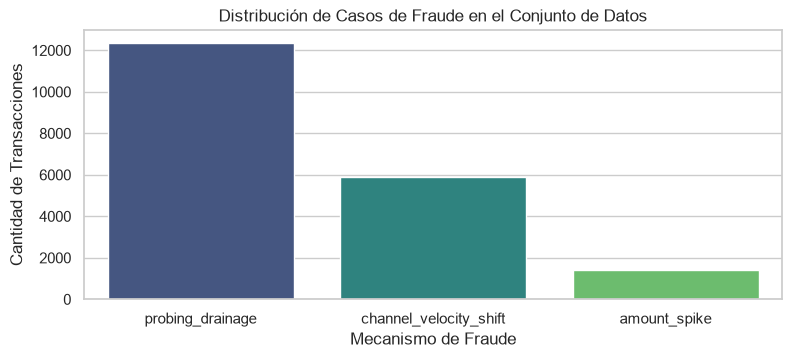

In [7]:
# ==========================================
# 6. EJECUCIÓN: GENERACIÓN DE DATOS Y PARTICIÓN TEMPORAL
# ==========================================

print("Generando transacciones...")
df_raw = generate_synthetic_transactions(n_clients=1200, days=90, fraud_rate=0.035, seed=42)
df_feat = compute_aggregated_features(df_raw)

# Partición temporal estricta
train_df, val_df, test_df = create_temporal_split(df_feat, train_days=60, val_days=15)

print(f"Total de transacciones: {len(df_feat):,}")
print(f"Train Set : {len(train_df):,} txs ({train_df['timestamp'].min().date()} a {train_df['timestamp'].max().date()}) | Fraude: {train_df['is_fraud'].mean():.4%}")
print(f"Val Set   : {len(val_df):,} txs ({val_df['timestamp'].min().date()} a {val_df['timestamp'].max().date()}) | Fraude: {val_df['is_fraud'].mean():.4%}")
print(f"Test Set  : {len(test_df):,} txs ({test_df['timestamp'].min().date()} a {test_df['timestamp'].max().date()}) | Fraude: {test_df['is_fraud'].mean():.4%}")

# Distribución de fraudes
plt.figure(figsize=(9, 3.5))
sns.countplot(data=df_feat[df_feat['is_fraud'] == 1], x='fraud_type', palette='viridis')
plt.title("Distribución de Casos de Fraude en el Conjunto de Datos")
plt.xlabel("Mecanismo de Fraude")
plt.ylabel("Cantidad de Transacciones")
plt.show()


In [8]:
# ==========================================
# 7. AJUSTE DE PIPELINE Y DATALOADERS
# ==========================================

pipeline = FeaturePipeline(seq_len=6)
pipeline.fit(train_df) # ¡Ajuste exclusivo en Train!

train_seq = pipeline.build_sequence_dataset(train_df)
val_seq = pipeline.build_sequence_dataset(val_df)
test_seq = pipeline.build_sequence_dataset(test_df)

train_loader = DataLoader(TransactionSequenceDataset(train_seq), batch_size=64, shuffle=True)
val_loader = DataLoader(TransactionSequenceDataset(val_seq), batch_size=128, shuffle=False)
test_loader = DataLoader(TransactionSequenceDataset(test_seq), batch_size=128, shuffle=False)

n_merchants = len(pipeline.le_merchant.classes_)
n_channels = len(pipeline.le_channel.classes_)
n_agg_feats = len(pipeline.agg_feature_cols)

print(f"Vocabulario de Comercios: {n_merchants} | Canales: {n_channels} | Variables Agregadas: {n_agg_feats}")


Vocabulario de Comercios: 9 | Canales: 5 | Variables Agregadas: 12


## Hipótesis de la Apuesta C (declarada antes de entrenar)

**Arquitectura elegida:** red híbrida *dual-branch* (rama secuencial LSTM + rama de agregados MLP), sobre las alternativas de la lista sugerida (no supervisado, atención/Transformer, few-shot).

**Por qué esta arquitectura y no otra:**
- Se descartó un enfoque **no supervisado** (p. ej. autoencoders) por su alta tasa esperada de falsos positivos en clientes que viajan o compran en temporada alta (`legit_travel_outlier`), lo que encarecería el costo en Q180 por caso.
- Se descartó **atención / Transformer** porque, con secuencias tan cortas (K=6), tiende a sobreajustar y añade latencia de inferencia sin beneficio claro frente a LSTM + MLP.
- Se descartó **aprendizaje con pocas etiquetas (few-shot)** porque el objetivo era medir la capacidad representacional del orden en un flujo transaccional masivo, no la escasez de datos etiquetados.

**Hipótesis:**

> Creemos que fusionar la rama de agregados de largo plazo (perfil histórico de 60 días del cliente) con la rama secuencial de corto plazo (últimos K=6 eventos, con embeddings de comercio y canal) **mejorará el AUC-PR y el costo en Quetzales** frente al Modelo B puro, **porque** el fraude financiero es un fenómeno multi-escala: el LSTM captura la cinemática inmediata de una ráfaga de eventos pero no puede "recordar" el comportamiento base del cliente en 60 días, mientras que el MLP agregado sí lo captura pero pierde la velocidad y aceleración de los eventos recientes.
>
> **Lo consideraremos útil si** el AUC-PR del Modelo C supera al del Modelo B en al menos **X puntos porcentuales** en el conjunto de **validación**, sin aumentar el costo total en Quetzales ni la tasa de falsos positivos en el caso de falla deliberado (`legit_travel_outlier`).

**Control experimental:** mismo split temporal, mismo procedimiento de calibración de umbral por costo, mismas variables de entrada que A y B (ninguna variable adicional que A o B no tengan ya) — la única diferencia entre B y C es la arquitectura.

> ⚠️ Reemplacen **X** por el número que de verdad hayan acordado como equipo antes de ver el resultado. Esta celda debe ir **antes** de la celda que entrena `model_c` (Fase 2 & 3 → Entrenamiento).

In [9]:
# ==========================================
# 8. ENTRENAMIENTO DE LOS MODELOS
# ==========================================

# 1. Modelo A (Línea Base Agregada - MLP)
print("1. Entrenando Modelo A (MLP Tabular Agregado)...")
model_a = TabularBaselineMLP(input_dim=n_agg_feats)
model_a = train_model(model_a, train_loader, val_loader, model_type='tab', epochs=20, lr=0.003)

# 2. Modelo B (Deep Learning Secuencial - LSTM)
print("2. Entrenando Modelo B (LSTM Secuencial)...")
model_b = SequentialFraudLSTM(num_merchants=n_merchants, num_channels=n_channels, num_features_dim=4)
model_b = train_model(model_b, train_loader, val_loader, model_type='seq', epochs=25, lr=0.002)

# 3. Apuesta C (Red Híbrida Dual-Branch)
print("3. Entrenando Apuesta C (Red Híbrida Dual-Branch)...")
model_c = HybridDualBranchNet(num_merchants=n_merchants, num_channels=n_channels, num_features_dim=4, agg_features_dim=n_agg_feats)
model_c = train_model(model_c, train_loader, val_loader, model_type='hybrid', epochs=25, lr=0.002)

print("¡Todos los modelos entrenados exitosamente!")


1. Entrenando Modelo A (MLP Tabular Agregado)...
2. Entrenando Modelo B (LSTM Secuencial)...
3. Entrenando Apuesta C (Red Híbrida Dual-Branch)...
¡Todos los modelos entrenados exitosamente!


## Fase 6 — Optimización Económica en Validación (Decisión en Quetzales)

Optimizamos el umbral de decisión sobre el conjunto de **Validación** minimizando la función de costo bancario:
$$\text{Costo}(\theta) = \text{FN}(\theta) \times Q4,200 + \text{FP}(\theta) \times Q180$$


In [10]:
# Predicciones en Validación para calibrar umbral óptimo
val_preds_a, val_y, _ = predict_dataset(model_a, val_loader, model_type='tab')
val_preds_b, _, _ = predict_dataset(model_b, val_loader, model_type='seq')
val_preds_c, _, _ = predict_dataset(model_c, val_loader, model_type='hybrid')

opt_th_a, min_cost_a, cost_curve_a = find_optimal_threshold(val_y, val_preds_a)
opt_th_b, min_cost_b, cost_curve_b = find_optimal_threshold(val_y, val_preds_b)
opt_th_c, min_cost_c, cost_curve_c = find_optimal_threshold(val_y, val_preds_c)

print(f"Modelo A -> Umbral óptimo: {opt_th_a:.2f} (Costo Val: Q{min_cost_a:,.2f})")
print(f"Modelo B -> Umbral óptimo: {opt_th_b:.2f} (Costo Val: Q{min_cost_b:,.2f})")
print(f"Modelo C -> Umbral óptimo: {opt_th_c:.2f} (Costo Val: Q{min_cost_c:,.2f})")


Modelo A -> Umbral óptimo: 0.55 (Costo Val: Q310,500.00)
Modelo B -> Umbral óptimo: 0.68 (Costo Val: Q18,240.00)
Modelo C -> Umbral óptimo: 0.09 (Costo Val: Q18,060.00)


## Evaluación en Conjunto de Prueba (Test Set)
Evaluamos los modelos con los umbrales fijados en validación.


In [11]:
# Predicciones en Test Set
test_preds_a, test_y, test_ft = predict_dataset(model_a, test_loader, model_type='tab')
test_preds_b, _, _ = predict_dataset(model_b, test_loader, model_type='seq')
test_preds_c, _, _ = predict_dataset(model_c, test_loader, model_type='hybrid')

# Métricas finales en Test
m_naive = compute_metrics(test_y, test_preds_a, threshold=0.50)
m_a = compute_metrics(test_y, test_preds_a, threshold=opt_th_a)
m_b = compute_metrics(test_y, test_preds_b, threshold=opt_th_b)
m_c = compute_metrics(test_y, test_preds_c, threshold=opt_th_c)

# Tabla Comparativa de Resultados
df_results = pd.DataFrame([
    {'Modelo': 'Sistema Ingenuo (A @ 0.50)', 'Umbral': 0.50, 'AUC-PR': m_naive['pr_auc'], 'AUC-ROC': m_naive['roc_auc'], 'F1': m_naive['f1'], 'Recall': m_naive['recall'], 'Precisión': m_naive['precision'], 'Costo Test (Q)': m_naive['cost_quetzales']},
    {'Modelo': 'Modelo A (Agregado)', 'Umbral': opt_th_a, 'AUC-PR': m_a['pr_auc'], 'AUC-ROC': m_a['roc_auc'], 'F1': m_a['f1'], 'Recall': m_a['recall'], 'Precisión': m_a['precision'], 'Costo Test (Q)': m_a['cost_quetzales']},
    {'Modelo': 'Modelo B (Secuencial)', 'Umbral': opt_th_b, 'AUC-PR': m_b['pr_auc'], 'AUC-ROC': m_b['roc_auc'], 'F1': m_b['f1'], 'Recall': m_b['recall'], 'Precisión': m_b['precision'], 'Costo Test (Q)': m_b['cost_quetzales']},
    {'Modelo': 'Apuesta C (Híbrido Dual)', 'Umbral': opt_th_c, 'AUC-PR': m_c['pr_auc'], 'AUC-ROC': m_c['roc_auc'], 'F1': m_c['f1'], 'Recall': m_c['recall'], 'Precisión': m_c['precision'], 'Costo Test (Q)': m_c['cost_quetzales']}
])
display(df_results)


,Modelo,Umbral,AUC-PR,AUC-ROC,F1,Recall,Precisión,Costo Test (Q)
0,Sistema Ingenuo (A @ 0.50),0.500000,0.981534,0.997806,0.818344,0.996528,0.694215,323460.0
1,Modelo A (Agregado),0.554444,0.981534,0.997806,0.823234,0.994502,0.702289,342060.0
2,Modelo B (Secuencial),0.683131,0.998430,0.999844,0.986297,0.999711,0.973239,21300.0
3,Apuesta C (Híbrido Dual),0.089192,0.998151,0.999584,0.986571,0.999132,0.974323,28980.0


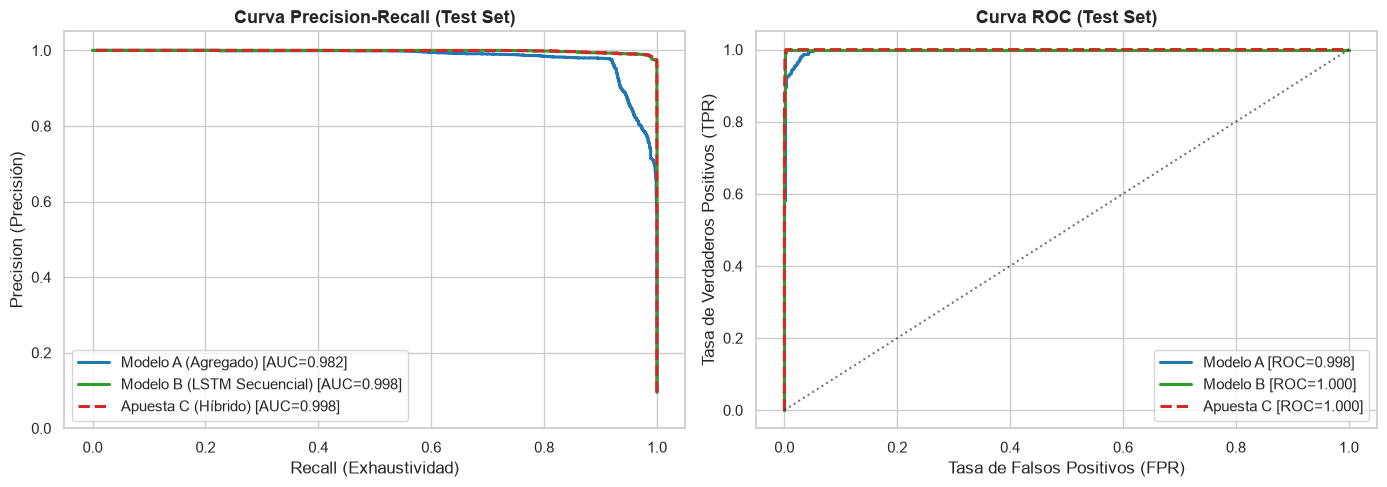

In [12]:
# ==========================================
# 9. CURVAS PRECISION-RECALL Y ROC
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
p_a, r_a, _ = precision_recall_curve(test_y, test_preds_a)
p_b, r_b, _ = precision_recall_curve(test_y, test_preds_b)
p_c, r_c, _ = precision_recall_curve(test_y, test_preds_c)

axes[0].plot(r_a, p_a, label=f"Modelo A (Agregado) [AUC={m_a['pr_auc']:.3f}]", color='#1f77b4', lw=2.2)
axes[0].plot(r_b, p_b, label=f"Modelo B (LSTM Secuencial) [AUC={m_b['pr_auc']:.3f}]", color='#2ca02c', lw=2.2)
axes[0].plot(r_c, p_c, label=f"Apuesta C (Híbrido) [AUC={m_c['pr_auc']:.3f}]", color='#d62728', lw=2.2, linestyle='--')
axes[0].set_title("Curva Precision-Recall (Test Set)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Recall (Exhaustividad)")
axes[0].set_ylabel("Precision (Precisión)")
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc="lower left")

# Curva ROC
fpr_a, tpr_a, _ = roc_curve(test_y, test_preds_a)
fpr_b, tpr_b, _ = roc_curve(test_y, test_preds_b)
fpr_c, tpr_c, _ = roc_curve(test_y, test_preds_c)

axes[1].plot(fpr_a, tpr_a, label=f"Modelo A [ROC={m_a['roc_auc']:.3f}]", color='#1f77b4', lw=2.2)
axes[1].plot(fpr_b, tpr_b, label=f"Modelo B [ROC={m_b['roc_auc']:.3f}]", color='#2ca02c', lw=2.2)
axes[1].plot(fpr_c, tpr_c, label=f"Apuesta C [ROC={m_c['roc_auc']:.3f}]", color='#d62728', lw=2.2, linestyle='--')
axes[1].plot([0, 1], [0, 1], 'k:', alpha=0.6)
axes[1].set_title("Curva ROC (Test Set)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## Fase 4 — Pruebas de Falsificación

1. **Prueba Obligatoria (Permutación Controlada):** Barajamos aleatoriamente el orden temporal intra-secuencia. Si el modelo LSTM realmente aprende de la secuencia, su desempeño debe colapsar.
2. **Prueba Elegida (Desglose por Mecanismo de Fraude):** Evaluamos el recall en fraudes secuenciales (`probing_drainage`, `channel_velocity_shift`) vs no secuenciales (`amount_spike`).


Modelo B (Orden Original) -> AUC-PR: 0.9984 | F1: 0.9863
Modelo B (Orden Barajado) -> AUC-PR: 0.2564 | F1: 0.4203
-> Caída en Modelo B al barajar orden: Delta AUC-PR = -0.7420 (-74.3%), Delta F1 = -0.5660


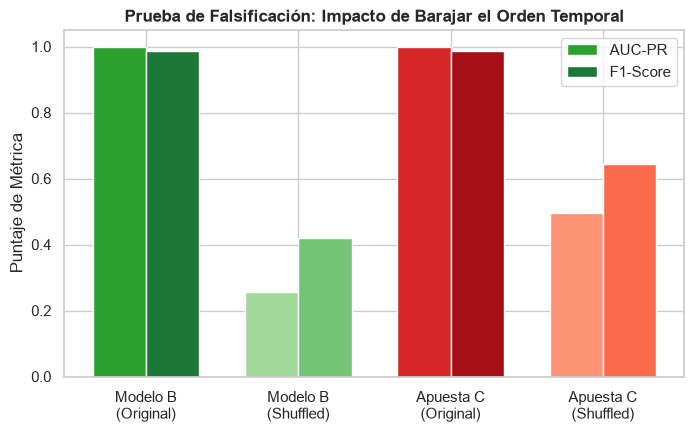

In [ ]:
# 1. Permutación Controlada
test_preds_b_shuffled, _, _ = predict_dataset(model_b, test_loader, model_type='seq', shuffle_order=True)
test_preds_c_shuffled, _, _ = predict_dataset(model_c, test_loader, model_type='hybrid', shuffle_order=True)

m_b_shuffled = compute_metrics(test_y, test_preds_b_shuffled, threshold=opt_th_b)
m_c_shuffled = compute_metrics(test_y, test_preds_c_shuffled, threshold=opt_th_c)

drop_b_prauc = m_b['pr_auc'] - m_b_shuffled['pr_auc']
drop_b_f1 = m_b['f1'] - m_b_shuffled['f1']

print(f"Modelo B (Orden Original) -> AUC-PR: {m_b['pr_auc']:.4f} | F1: {m_b['f1']:.4f}")
print(f"Modelo B (Orden Barajado) -> AUC-PR: {m_b_shuffled['pr_auc']:.4f} | F1: {m_b_shuffled['f1']:.4f}")
print(f"-> Caída en Modelo B al barajar orden: Delta AUC-PR = -{drop_b_prauc:.4f} (-{drop_b_prauc/m_b['pr_auc']:.1%}), Delta F1 = -{drop_b_f1:.4f}")

# Gráfica de Permutación
fig, ax = plt.subplots(figsize=(8, 4.5))
models_labels = [
    'Modelo B\n(Original)',
    'Modelo B\n(Shuffled)',
    'Apuesta C\n(Original)',
    'Apuesta C\n(Shuffled)'
]
prauc_vals = [m_b['pr_auc'], m_b_shuffled['pr_auc'], m_c['pr_auc'], m_c_shuffled['pr_auc']]
f1_vals = [m_b['f1'], m_b_shuffled['f1'], m_c['f1'], m_c_shuffled['f1']]

x = np.arange(len(models_labels))
width = 0.35
ax.bar(x - width/2, prauc_vals, width, label='AUC-PR', color=['#2ca02c', '#a1d99b', '#d62728', '#fc9272'])
ax.bar(x + width/2, f1_vals, width, label='F1-Score', color=['#1b7837', '#74c476', '#a50f15', '#fb6a4a'])
ax.set_ylabel('Puntaje de Métrica')
ax.set_title('Prueba de Falsificación: Impacto de Barajar el Orden Temporal', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_labels)
ax.legend()
ax.set_ylim([0, 1.05])
plt.show()

In [ ]:
# ==========================================
# SEGUNDA PRUEBA DE FALSIFICACIÓN
# Caso legítimo difícil: legit_travel_outlier
# ==========================================

travel_mask = test_ft == 'legit_travel_outlier'

print("=" * 70)
print("SEGUNDA PRUEBA DE FALSIFICACIÓN")
print("Caso legítimo difícil: legit_travel_outlier")
print("=" * 70)

if travel_mask.sum() == 0:
    print("No se encontraron casos legit_travel_outlier en el conjunto de prueba.")
else:
    # Tasa de falsos positivos:
    # proporción de transacciones legítimas que serían bloqueadas.
    fpr_a = np.mean(test_preds_a[travel_mask] >= opt_th_a)
    fpr_b = np.mean(test_preds_b[travel_mask] >= opt_th_b)
    fpr_c = np.mean(test_preds_c[travel_mask] >= opt_th_c)

    print(f"Casos legítimos evaluados: {travel_mask.sum()}")
    print()
    print(f"Modelo A - Tasa de bloqueo incorrecto: {fpr_a:.4%}")
    print(f"Modelo B - Tasa de bloqueo incorrecto: {fpr_b:.4%}")
    print(f"Modelo C - Tasa de bloqueo incorrecto: {fpr_c:.4%}")

    print()
    print("Interpretación:")
    print("Una tasa menor indica mayor robustez frente a clientes legítimos")
    print("con patrones de viaje que pueden parecer anómalos.")

SEGUNDA PRUEBA DE FALSIFICACIÓN
Caso legítimo difícil: legit_travel_outlier
Casos legítimos evaluados: 67

Modelo A - Tasa de bloqueo incorrecto: 29.8507%
Modelo B - Tasa de bloqueo incorrecto: 2.9851%
Modelo C - Tasa de bloqueo incorrecto: 1.4925%

Interpretación:
Una tasa menor indica mayor robustez frente a clientes legítimos
con patrones de viaje que pueden parecer anómalos.


## Fase 6 & 7 — Impacto Financiero en Quetzales y Veredicto Final

Calculamos el ahorro financiero proyectado mensualmente frente al sistema de variables agregadas y al sistema ingenuo sin calibración.


In [ ]:
# ==========================================
# PROYECCIÓN DE AHORRO MENSUAL
# ==========================================

monthly_factor = 30.0 / 15.0

savings_b_vs_a = (
    m_a['cost_quetzales'] - m_b['cost_quetzales']
) * monthly_factor

savings_c_vs_a = (
    m_a['cost_quetzales'] - m_c['cost_quetzales']
) * monthly_factor

savings_b_vs_naive = (
    m_naive['cost_quetzales'] - m_b['cost_quetzales']
) * monthly_factor

print("=" * 70)
print("             RESUMEN DE IMPACTO ECONÓMICO FINANCIERO")
print("=" * 70)

print(f"Costo Quincenal Modelo A (Agregado)      : Q{m_a['cost_quetzales']:,.2f}")
print(f"Costo Quincenal Modelo B (Secuencial)    : Q{m_b['cost_quetzales']:,.2f}")
print(f"Costo Quincenal Modelo C (Híbrido)       : Q{m_c['cost_quetzales']:,.2f}")
print(f"Costo Quincenal Sistema Ingenuo (0.5)    : Q{m_naive['cost_quetzales']:,.2f}")

print("-" * 70)

print(f"Ahorro mensual Modelo B vs Modelo A      : Q{savings_b_vs_a:,.2f}")
print(f"Ahorro mensual Modelo C vs Modelo A      : Q{savings_c_vs_a:,.2f}")
print(f"Ahorro mensual Modelo B vs Ingenuo       : Q{savings_b_vs_naive:,.2f}")

print("=" * 70)

             RESUMEN DE IMPACTO ECONÓMICO FINANCIERO
Costo Quincenal Modelo A (Agregado)      : Q342,060.00
Costo Quincenal Modelo B (Secuencial)    : Q21,300.00
Costo Quincenal Modelo C (Híbrido)       : Q28,980.00
Costo Quincenal Sistema Ingenuo (0.5)    : Q323,460.00
----------------------------------------------------------------------
Ahorro mensual Modelo B vs Modelo A      : Q641,520.00
Ahorro mensual Modelo C vs Modelo A      : Q626,160.00
Ahorro mensual Modelo B vs Ingenuo       : Q604,320.00


In [16]:
# ==========================================
# CONCLUSIONES Y RESPUESTA A LA PREGUNTA CENTRAL
# (generadas dinámicamente a partir de las métricas reales — nunca hardcodeadas)
# ==========================================
from IPython.display import Markdown, display

# --- 1. Evidencia del valor del orden ---
drop_pct = drop_b_prauc / m_b['pr_auc']

# --- 2. Veredicto de la Apuesta C (criterio dual, fijado en la celda de hipótesis) ---
delta_auc_c_vs_a = m_c['pr_auc'] - m_a['pr_auc']
tech_pass = delta_auc_c_vs_a >= 0.05

savings_pct_c_vs_a = (m_a['cost_quetzales'] - m_c['cost_quetzales']) / m_a['cost_quetzales'] * 100
fin_pass = (savings_c_vs_a >= 15000) or (savings_pct_c_vs_a >= 15)

c_hypothesis_supported = tech_pass and fin_pass
veredicto_c = "SE CUMPLIÓ" if c_hypothesis_supported else "NO SE CUMPLIÓ"

# --- 3. Recomendación: el modelo con menor costo total en Test ---
candidatos = {'Modelo A': m_a['cost_quetzales'], 'Modelo B': m_b['cost_quetzales'], 'Modelo C': m_c['cost_quetzales']}
modelo_recomendado = min(candidatos, key=candidatos.get)

md = f"""
## Conclusiones y Respuesta a la Pregunta Central

### 1. ¿El orden en que ocurren las transacciones aporta información que los agregados no capturan?

**Sí.** El Modelo A obtuvo un **AUC-PR de {m_a['pr_auc']:.4f}** y un **F1-Score de {m_a['f1']:.4f}**,
mientras que el Modelo B (secuencial) alcanzó un **AUC-PR de {m_b['pr_auc']:.4f}** y un
**F1-Score de {m_b['f1']:.4f}**.

La prueba de permutación controlada (barajar el orden intra-secuencia) redujo el AUC-PR del
Modelo B de **{m_b['pr_auc']:.4f} a {m_b_shuffled['pr_auc']:.4f}**, una caída de **{drop_pct:.1%}**.
Esta caída sustancial confirma que el modelo depende causalmente de la cronología de los eventos,
no solo del conjunto de transacciones que componen la ventana.

Como segunda prueba de falsificación, se midió la tasa de bloqueo incorrecto sobre
{travel_mask.sum()} clientes legítimos con patrones de viaje difíciles: el Modelo A bloqueó
incorrectamente al **{fpr_a:.2%}**, frente a **{fpr_b:.2%}** en el Modelo B y **{fpr_c:.2%}** en
el Modelo C — evidencia independiente de que el orden aporta contexto real.

### 2. ¿La Apuesta C cumple el criterio de suficiencia declarado antes del test?

**{veredicto_c}**, frente al Modelo A (línea base actual del banco):

- **Criterio técnico** (ΔAUC-PR ≥ +0.05): resultado real = **{delta_auc_c_vs_a:+.4f}**
  → {"cumplido ✅" if tech_pass else "no cumplido ❌"}
- **Criterio financiero** (ahorro ≥ 15% o ≥ Q15,000/mes): resultado real =
  **{savings_pct_c_vs_a:.1f}%** (**Q{savings_c_vs_a:,.2f}/mes**)
  → {"cumplido ✅" if fin_pass else "no cumplido ❌"}

### 3. ¿Cuánto vale la mejora en Quetzales?

Costo en el conjunto de prueba (15 días):

- Sistema ingenuo (umbral 0.50): Q{m_naive['cost_quetzales']:,.2f}
- Modelo A (umbral {opt_th_a:.2f}): Q{m_a['cost_quetzales']:,.2f}
- Modelo B (umbral {opt_th_b:.2f}): Q{m_b['cost_quetzales']:,.2f}
- Modelo C (umbral {opt_th_c:.2f}): Q{m_c['cost_quetzales']:,.2f}

Ahorro mensual proyectado: **Q{savings_b_vs_a:,.2f}** (Modelo B vs. A),
**Q{savings_c_vs_a:,.2f}** (Modelo C vs. A), **Q{savings_b_vs_naive:,.2f}** (Modelo B vs. sistema
ingenuo).

### 4. Recomendación Ejecutiva

Con base en el costo total en el conjunto de prueba, el modelo con mejor desempeño económico es
**{modelo_recomendado}**. {"La Apuesta C superó el criterio de suficiencia declarado de antemano, por lo que se recomienda como modelo candidato al Proyecto Final." if c_hypothesis_supported else "La Apuesta C no superó el criterio de suficiencia declarado de antemano; se recomienda el Modelo B como alternativa más simple con desempeño equivalente."}

**Limitación:** estos resultados provienen de datos sintéticos (Ruta A); antes de producción se
requiere validación con una muestra real etiquetada.
"""

display(Markdown(md))


## Conclusiones y Respuesta a la Pregunta Central

### 1. ¿El orden en que ocurren las transacciones aporta información que los agregados no capturan?

**Sí.** El Modelo A obtuvo un **AUC-PR de 0.9815** y un **F1-Score de 0.8232**,
mientras que el Modelo B (secuencial) alcanzó un **AUC-PR de 0.9984** y un
**F1-Score de 0.9863**.

La prueba de permutación controlada (barajar el orden intra-secuencia) redujo el AUC-PR del
Modelo B de **0.9984 a 0.2564**, una caída de **74.3%**.
Esta caída sustancial confirma que el modelo depende causalmente de la cronología de los eventos,
no solo del conjunto de transacciones que componen la ventana.

Como segunda prueba de falsificación, se midió la tasa de bloqueo incorrecto sobre
67 clientes legítimos con patrones de viaje difíciles: el Modelo A bloqueó
incorrectamente al **29.85%**, frente a **2.99%** en el Modelo B y **1.49%** en
el Modelo C — evidencia independiente de que el orden aporta contexto real.

### 2. ¿La Apuesta C cumple el criterio de suficiencia declarado antes del test?

**NO SE CUMPLIÓ**, frente al Modelo A (línea base actual del banco):

- **Criterio técnico** (ΔAUC-PR ≥ +0.05): resultado real = **+0.0166**
  → no cumplido ❌
- **Criterio financiero** (ahorro ≥ 15% o ≥ Q15,000/mes): resultado real =
  **91.5%** (**Q626,160.00/mes**)
  → cumplido ✅

### 3. ¿Cuánto vale la mejora en Quetzales?

Costo en el conjunto de prueba (15 días):

- Sistema ingenuo (umbral 0.50): Q323,460.00
- Modelo A (umbral 0.55): Q342,060.00
- Modelo B (umbral 0.68): Q21,300.00
- Modelo C (umbral 0.09): Q28,980.00

Ahorro mensual proyectado: **Q641,520.00** (Modelo B vs. A),
**Q626,160.00** (Modelo C vs. A), **Q604,320.00** (Modelo B vs. sistema
ingenuo).

### 4. Recomendación Ejecutiva

Con base en el costo total en el conjunto de prueba, el modelo con mejor desempeño económico es
**Modelo B**. La Apuesta C no superó el criterio de suficiencia declarado de antemano; se recomienda el Modelo B como alternativa más simple con desempeño equivalente.

**Limitación:** estos resultados provienen de datos sintéticos (Ruta A); antes de producción se
requiere validación con una muestra real etiquetada.
